# DE-LU day-ahead price - EDA

Descriptive stats for `de_lu_features.parquet` . 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['figure.dpi'] = 110

df = pd.read_parquet('data/de_lu_features.parquet')  

# grab renewable component cols by name instead of hardcoding, less brittle
ren_cols = [c for c in df.columns if 'Solar' in c or 'Wind' in c]

print(len(df), 'rows |', df.index.min(), '->', df.index.max())
print('renewable cols:', ren_cols)
df.head()

52609 rows | 2019-01-01 00:00:00+01:00 -> 2025-01-01 00:00:00+01:00
renewable cols: ['Solar', 'Wind Offshore', 'Wind Onshore']


,price,load_fc,Solar,Wind Offshore,Wind Onshore,renewables_fc,residual_load,hour,dow,month,is_weekend,is_holiday,price_lag_24,price_lag_168,price_roll168_mean,price_roll168_std,price_roll24_std
2019-01-01 00:00:00+01:00,28.32,43647.5450,0.0,5068.9000,18879.7900,23948.6900,19698.8550,0,1,1,0,0,NaN,NaN,NaN,NaN,NaN
2019-01-01 01:00:00+01:00,10.07,41692.5650,0.0,5042.4425,20626.5625,25669.0050,16023.5600,1,1,1,0,0,NaN,NaN,NaN,NaN,NaN
2019-01-01 02:00:00+01:00,-4.08,40587.2325,0.0,5028.4175,22355.6850,27384.1025,13203.1300,2,1,1,0,0,NaN,NaN,NaN,NaN,NaN
2019-01-01 03:00:00+01:00,-9.91,40308.2500,0.0,4977.6500,24032.4775,29010.1275,11298.1225,3,1,1,0,0,NaN,NaN,NaN,NaN,NaN
2019-01-01 04:00:00+01:00,-7.41,40659.5750,0.0,4907.4000,25452.1675,30359.5675,10300.0075,4,1,1,0,0,NaN,NaN,NaN,NaN,NaN


## Summary stats



In [14]:
cols = ['price', 'load_fc', 'renewables_fc', 'residual_load']
df[cols].describe().T.round(1)



,count,mean,std,min,25%,50%,75%,max
price,52603.0,95.7,99.0,-500.0,36.5,66.2,115.2,936.3
load_fc,52558.0,54768.2,9308.6,30893.1,47157.1,54637.5,62506.5,78154.4
renewables_fc,52609.0,20559.2,12522.8,0.0,10095.9,18714.2,29389.3,70016.0
residual_load,52558.0,34211.2,13069.6,-13601.9,25736.5,35084.3,43381.9,70888.3


## Price over time

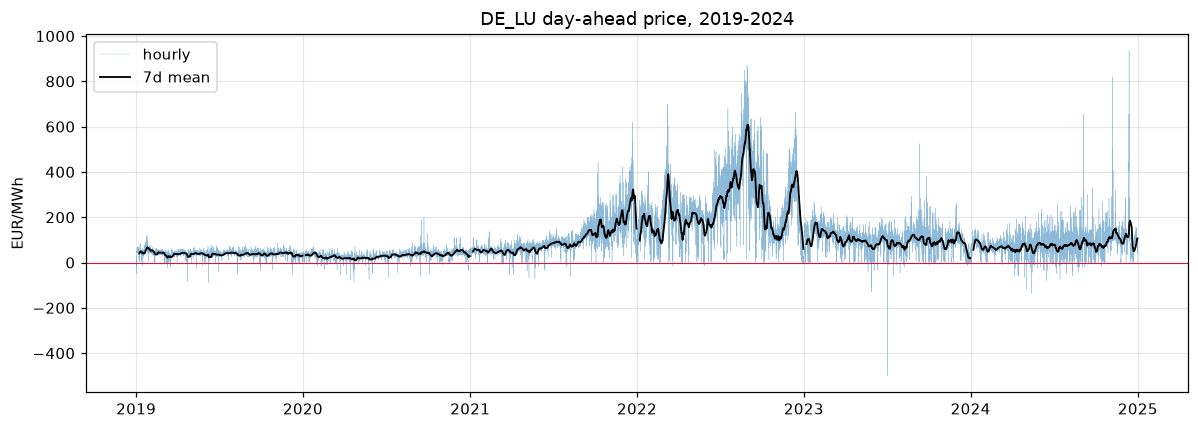

In [6]:
fig, ax = plt.subplots()
ax.plot(df.index, df['price'], lw=0.25, alpha=0.5, label='hourly')
ax.plot(df.index, df['price'].rolling(168).mean(), color='black', lw=1.2, label='7d mean')
ax.axhline(0, color='crimson', lw=0.7)
ax.set_ylabel('EUR/MWh')
ax.set_title('DE_LU day-ahead price, 2019-2024')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### zoom on the crisis window



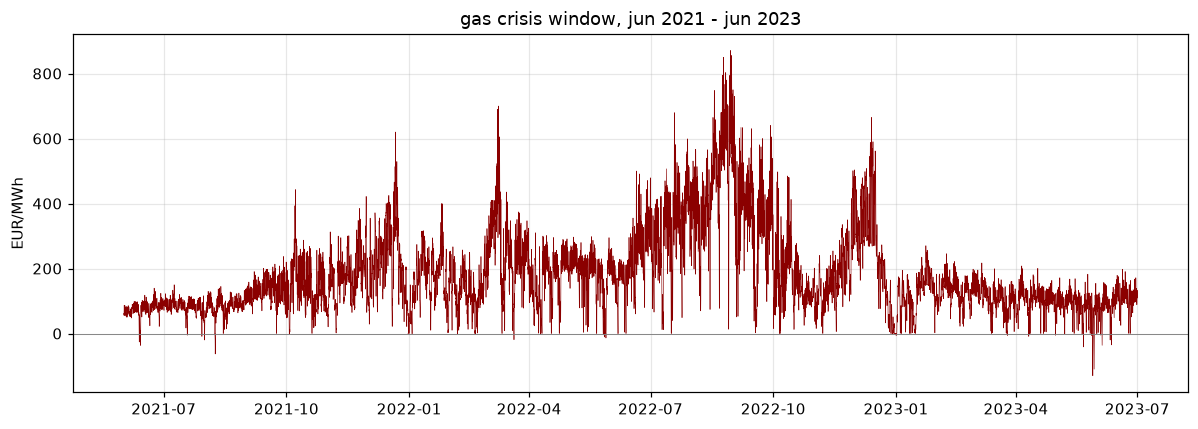

In [7]:
crisis = df.loc['2021-06':'2023-06', 'price']

fig, ax = plt.subplots()
ax.plot(crisis.index, crisis, lw=0.4, color='darkred')
ax.axhline(0, color='grey', lw=0.6)
ax.set_ylabel('EUR/MWh')
ax.set_title('gas crisis window, jun 2021 - jun 2023')
plt.tight_layout()
plt.show()

## Distribution - heavy tails vs gaussian

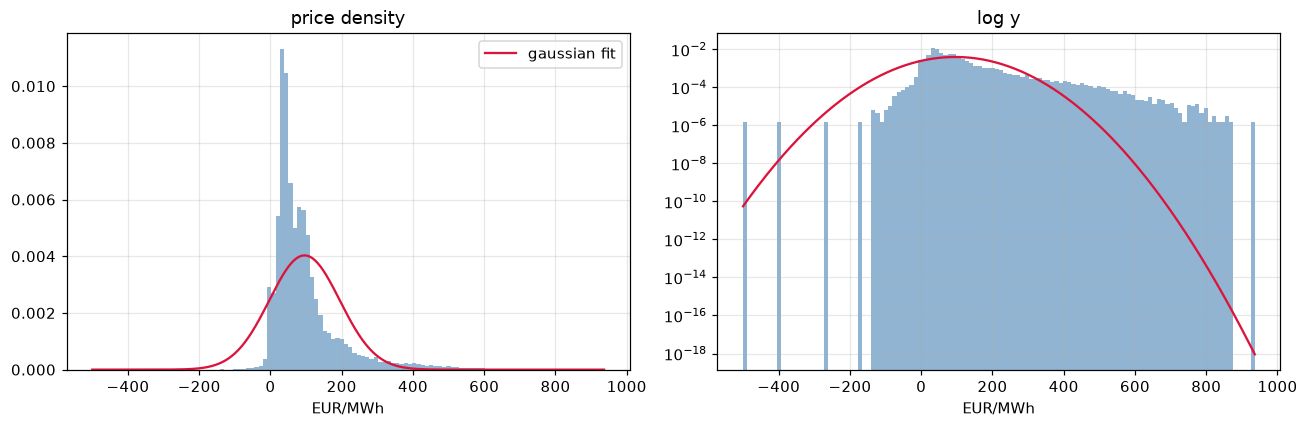

   0.1%      -65.2 EUR/MWh
   1.0%       -8.5 EUR/MWh
   5.0%        5.0 EUR/MWh
  50.0%       66.2 EUR/MWh
  95.0%      299.9 EUR/MWh
  99.0%      500.1 EUR/MWh
  99.9%      703.2 EUR/MWh


In [17]:
p = df['price'].dropna()
mu, sigma = p.mean(), p.std()
x = np.linspace(p.min(), p.max(), 400)
normal_pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(p, bins=120, density=True, alpha=0.6, color='steelblue')
axes[0].plot(x, normal_pdf, color='crimson', lw=1.5, label='gaussian fit')
axes[0].set_title('price density')
axes[0].set_xlabel('EUR/MWh')
axes[0].legend()

# same thing but log y - this is the one that actually makes the point
axes[1].hist(p, bins=120, density=True, alpha=0.6, color='steelblue')
axes[1].plot(x, normal_pdf, color='crimson', lw=1.5)
axes[1].set_yscale('log')
axes[1].set_title('log y')
axes[1].set_xlabel('EUR/MWh')

plt.tight_layout()
plt.show()

for q in [0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]:
    print(f'{q:>7.1%}  {p.quantile(q):>9.1f} EUR/MWh')

## Negative prices

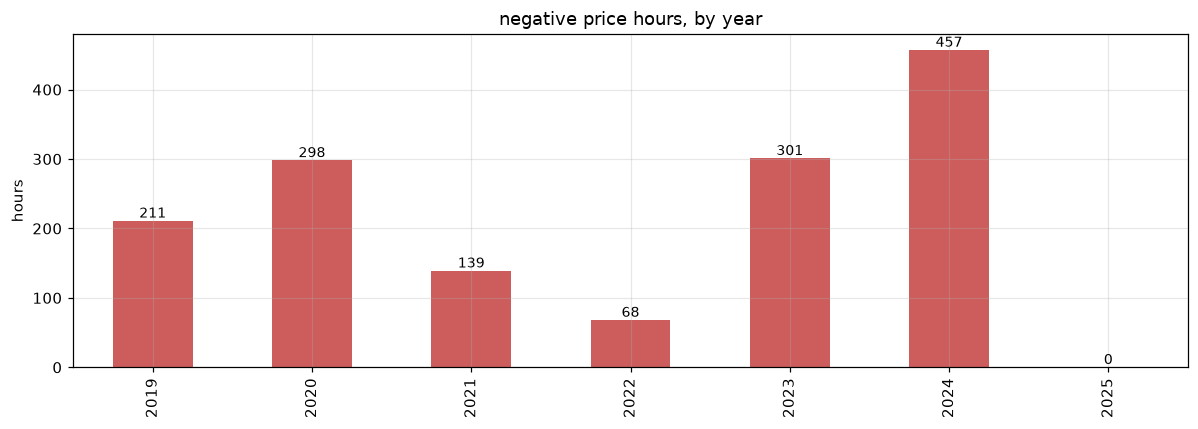

In [9]:
neg_hours = (df['price'] < 0).groupby(df.index.year).sum()

ax = neg_hours.plot(kind='bar', color='indianred')
ax.set_ylabel('hours')
ax.set_title('negative price hours, by year')
for i, v in enumerate(neg_hours):
    ax.text(i, v, str(int(v)), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## Daily / weekly seasonality

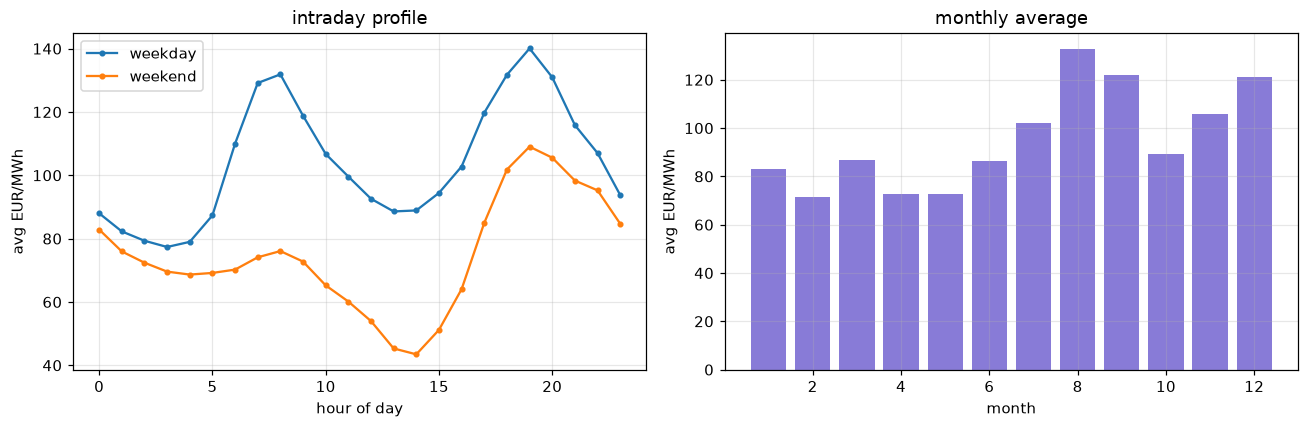

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

weekday = df[df['is_weekend'] == 0].groupby('hour')['price'].mean()
weekend = df[df['is_weekend'] == 1].groupby('hour')['price'].mean()
axes[0].plot(weekday.index, weekday, marker='o', ms=3, label='weekday')
axes[0].plot(weekend.index, weekend, marker='o', ms=3, label='weekend')
axes[0].set_xlabel('hour of day')
axes[0].set_ylabel('avg EUR/MWh')
axes[0].set_title('intraday profile')
axes[0].legend()

monthly = df.groupby('month')['price'].mean()
axes[1].bar(monthly.index, monthly, color='slateblue', alpha=0.8)
axes[1].set_xlabel('month')
axes[1].set_ylabel('avg EUR/MWh')
axes[1].set_title('monthly average')

plt.tight_layout()
plt.show()

## Residual load vs price, the merit order curve

Residual load (demand minus renewables) is basically the driver here.

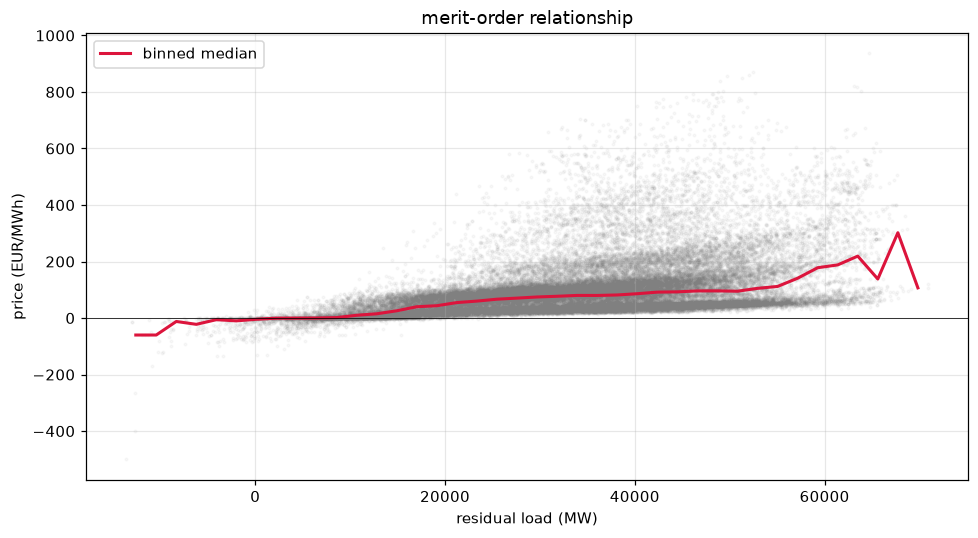

In [11]:
rl = df[['residual_load', 'price']].dropna()

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(rl['residual_load'], rl['price'], s=3, alpha=0.05, color='grey')

bins = pd.cut(rl['residual_load'], 40)
binned_median = rl.groupby(bins, observed=True)['price'].median()
centers = [iv.mid for iv in binned_median.index]

ax.plot(centers, binned_median.values, color='crimson', lw=2, label='binned median')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('residual load (MW)')
ax.set_ylabel('price (EUR/MWh)')
ax.set_title('merit-order relationship')
ax.legend()
plt.tight_layout()
plt.show()

## Autocorrelation - why lag_24 and lag_168

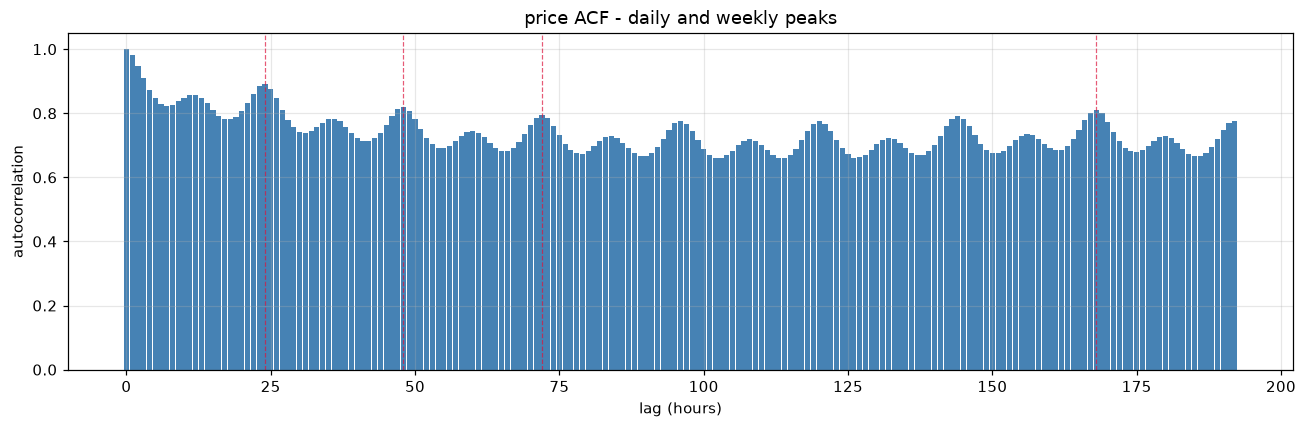

acf @ 24h: 0.891  @ 168h: 0.812


In [12]:
def acf(series, max_lag):
    s = series.dropna()
    s = s - s.mean()
    denom = (s ** 2).sum()
    return np.array([(s * s.shift(l)).sum() / denom for l in range(max_lag + 1)])

a = acf(df['price'], 192)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(a)), a, color='steelblue', width=0.9)
for L in (24, 48, 72, 168):
    ax.axvline(L, color='crimson', lw=0.8, ls='--', alpha=0.7)
ax.set_xlabel('lag (hours)')
ax.set_ylabel('autocorrelation')
ax.set_title('price ACF - daily and weekly peaks')
plt.tight_layout()
plt.show()

print('acf @ 24h:', round(a[24], 3), ' @ 168h:', round(a[168], 3))

## Missing data

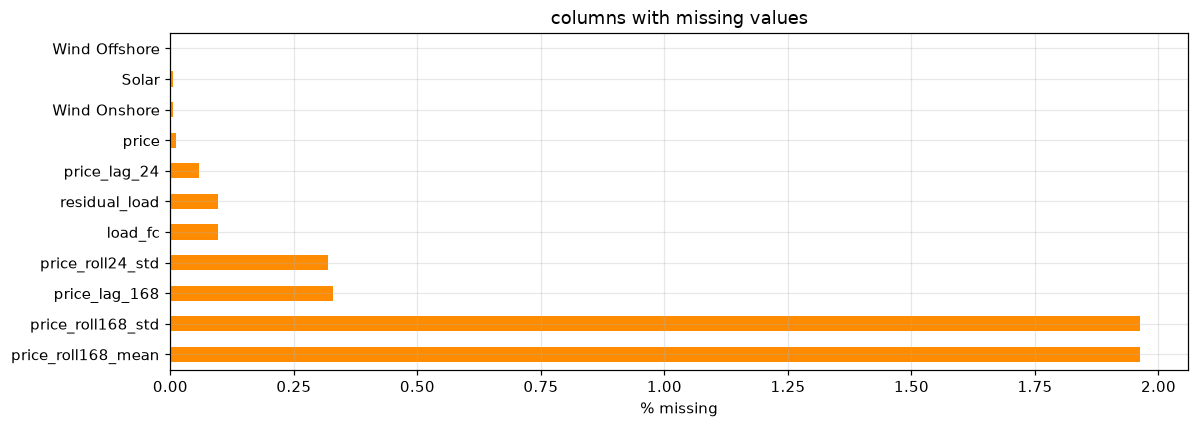

price_roll168_mean    1.961642
price_roll168_std     1.961642
price_lag_168         0.328841
price_roll24_std      0.319337
load_fc               0.096942
residual_load         0.096942
price_lag_24          0.057024
price                 0.011405
Wind Onshore          0.005702
Solar                 0.005702
Wind Offshore         0.001901
dtype: float64

In [13]:
nan_pct = (df.isna().mean() * 100).sort_values(ascending=False)
nan_pct = nan_pct[nan_pct > 0]

if len(nan_pct):
    ax = nan_pct.plot(kind='barh', color='darkorange')
    ax.set_xlabel('% missing')
    ax.set_title('columns with missing values')
    plt.tight_layout()
    plt.show()
else:
    print('no missing values')

nan_pct